<a href="https://colab.research.google.com/github/tungcheese/DEEPLEARNING/blob/main/baitap3/Depthwise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
%matplotlib inline

In [12]:
import torch
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [13]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

horse   car  bird truck


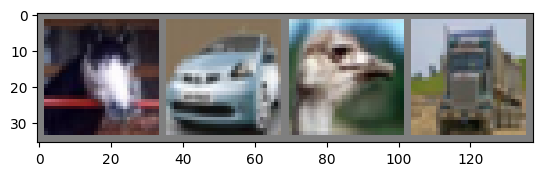

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)


# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

In [15]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class ChannelGate(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(ChannelGate, self).__init__()
        # if gate_channels // reduction_ratio == 0: #fixed for mobileNetV2
        #     reduction_ratio = gate_channels
        self.mlp = nn.Sequential(
            Flatten(),
            nn.Linear(gate_channels, gate_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(gate_channels // reduction_ratio, gate_channels)
            )
    def forward(self, x):
        squeeze_avg = F.avg_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
        channel_att = self.mlp(squeeze_avg)
        scale = torch.sigmoid(channel_att).unsqueeze(2).unsqueeze(3).expand_as(x)
        return x * scale

class SE(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(SE, self).__init__()
        self.ChannelGate = ChannelGate(gate_channels, reduction_ratio)
    def forward(self, x):
        x_out = self.ChannelGate(x)
        return x_out

In [22]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as T
##from models.SE_Attention import*

class modulenew(nn.Module):
    """Depthwise Separable Convolution"""
    def __init__(self, in_channels, out_channels, s):
        super().__init__()
        self.in_channels = in_channels # Store for potential skip connection logic
        self.out_channels = out_channels # Store for potential skip connection logic
        self.s = s # Store stride for skip connection logic

        self.dw1 = nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=3, stride=s, padding=1, groups=in_channels, dilation=1)
        self.dw2 = nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=3, stride=s, padding=2, groups=in_channels, dilation=2)
        # Fix: pwout should output 'out_channels' to align with the SE module's expected input
        self.pwout = nn.Conv2d(in_channels= 2*in_channels, out_channels=out_channels, kernel_size=1)
        # SE module should be initialized with 'out_channels' as it's applied after pwout
        self.SE = SE(out_channels, 16)

    def forward(self, x):
        x_ori = x
        x1 = F.relu(self.dw1(x))
        x2 = F.relu(self.dw2(x))
        x = torch.cat((x1, x2), dim=1)
        x = self.shuffle(x)
        x = F.relu(self.pwout(x))
        x = self.SE(x)
        if self.s==1 and x.size()==x_ori.size(): # This condition implicitly handles channel mismatches now
            x = x + x_ori
        return x

    def shuffle(self,x):
        num_group=2
        b, num_channels, height, width = x.data.size()
        group_channels = num_channels // num_group

        x = x.reshape(b, group_channels, num_group, height, width)
        x = x.permute(0, 2, 1, 3, 4)
        x = x.reshape(b, num_channels, height, width)
        return x

class PDPNet(nn.Module):
    def __init__(self, image_size,n_class):
        super(PDPNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.modulenew_1 = modulenew(in_channels=32,out_channels=64,s=1)
        self.modulenew_2 = modulenew(in_channels=64,out_channels=64,s=1)
        if image_size==32:
            self.modulenew_3 = modulenew(in_channels=64,out_channels=128,s=1)
        else:
            self.modulenew_3 = modulenew(in_channels=64,out_channels=128,s=2)
        self.modulenew_4 = modulenew(in_channels=128,out_channels=128,s=1)
        self.modulenew_5 = modulenew(in_channels=128,out_channels=256,s=2)
        self.modulenew_6 = modulenew(in_channels=256,out_channels=256,s=1)
        self.modulenew_7 = modulenew(in_channels=256,out_channels=256,s=2)
        self.modulenew_8 = modulenew(in_channels=256,out_channels=512,s=1)
        self.modulenew_9 = modulenew(in_channels=512,out_channels=512,s=2)
        self.conv2 = nn.Conv2d(in_channels=512, out_channels=1024, kernel_size=1, padding=0)
        self.avgpool = torch.nn.AdaptiveAvgPool2d(output_size=1)
        self.fc = nn.Linear(1024, n_class)#cifar-10
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.modulenew_1(x)
        x = self.modulenew_2(x)
        x = self.modulenew_3(x)
        x = self.modulenew_4(x)
        x = self.modulenew_5(x)
        x = self.modulenew_6(x)
        x = self.modulenew_7(x)
        x = self.modulenew_8(x)
        x = self.modulenew_9(x)
        x = self.conv2(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
net = PDPNet(image_size = 224,n_class =1000)
net.to(device)

from torchsummary import summary
print(net)
summary(net, (3, 32, 32))

PDPNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (modulenew_1): modulenew(
    (dw1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32)
    (dw2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2), groups=32)
    (pwout): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (SE): SE(
      (ChannelGate): ChannelGate(
        (mlp): Sequential(
          (0): Flatten()
          (1): Linear(in_features=64, out_features=4, bias=True)
          (2): ReLU()
          (3): Linear(in_features=4, out_features=64, bias=True)
        )
      )
    )
  )
  (modulenew_2): modulenew(
    (dw1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
    (dw2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2), groups=64)
    (pwout): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
    (SE): SE(
      (ChannelGate): ChannelGate(
        (mlp): Sequ